# TF-IDF Retrieval for Harry Potter Passages

This notebook demonstrates lexical retrieval using TF-IDF (Term Frequency-Inverse Document Frequency) on the Harry Potter text chunks.

Steps covered:
1. Load the preprocessed text chunks
2. Initialize the TF-IDF retriever
3. Perform example searches
4. Analyze the results
5. Discuss the limitations of TF-IDF

## Setup

First, let's import the necessary libraries and modules.

In [1]:
import sys
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Add the src directory to the path so we can import our modules
sys.path.append('../src')

from preprocessing import load_chunks
from tfidf_retrieval import TFIDFRetriever, run_example_searches, analyze_tfidf_issues

[nltk_data] Downloading package punkt_tab to /home/user/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


## 1. Load the Preprocessed Text Chunks

We'll load the text chunks that were created in the previous notebook.

In [2]:
# Load the chunks
chunks = load_chunks('../data/text_chunks.json')

print(f"Loaded {len(chunks)} chunks")
print(f"First chunk: {chunks[0][:150]}...")

Loaded 972 chunks
First chunk: Harry Potter and the Sorcerer's Stone Mr. and Mrs. Dursley, of number four, Privet Drive, were proud to say that they were perfectly normal, thank you...


## 2. Initialize the TF-IDF Retriever

Now we'll initialize the TF-IDF retriever with our text chunks.

In [3]:
# Initialize the TF-IDF retriever
retriever = TFIDFRetriever(
    chunks,
    stop_words='english',
    ngram_range=(1, 2),  # Include both unigrams and bigrams
    max_df=0.85,         # Ignore terms that appear in >85% of documents
    min_df=2             # Ignore terms that appear in <2 documents
)

TF-IDF matrix shape: (972, 5662)


Let's examine the vocabulary size and some of the terms in the TF-IDF matrix.

In [4]:
# Get vocabulary size
vocab_size = len(retriever.vectorizer.vocabulary_)
print(f"Vocabulary size: {vocab_size} terms")

# Get some example terms from the vocabulary
vocab = retriever.vectorizer.vocabulary_
terms = list(vocab.keys())
print(f"\nSample terms from vocabulary:")
for term in sorted(terms[:20]):
    print(f"- {term}")

Vocabulary size: 5662 terms

Sample terms from vocabulary:
- drive
- dursley
- expect
- harry
- involved
- mr
- mrs
- mysterious
- normal
- number
- people
- perfectly
- potter
- privet
- proud
- say
- sorcerer
- stone
- strange
- thank


## 3. Perform Example Searches

Now we'll perform some example searches to demonstrate the TF-IDF retrieval.

In [5]:
# Define example queries
example_queries = [
    "Harry's first day at Hogwarts",
    "Quidditch match rules",
    "Voldemort and the Philosopher's Stone"
]

# Create results directory if it doesn't exist
os.makedirs('../results', exist_ok=True)

# Run example searches
results = run_example_searches(retriever, example_queries, '../results/tfidf_results.json')


Query: Harry's first day at Hogwarts
Result 1 (Score: 0.2110):
And the school bellowed: "Hogwarts, Hogwarts, Hoggy Warty Hogwarts, Teach us something please, Whether we be old and bald Or young with scabby knees, ...
Result 2 (Score: 0.2072):
Everyone starts at the beginning at Hogwarts, you'll be just fine. just be yerself. I know it's hard. Yeh've been singled out, an' that's always hard....
Result 3 (Score: 0.1863):
Malfoy couldn't believe his eyes when he saw that Harry and Ron were still at Hogwarts the next day, looking tired but perfectly cheerful. Indeed, by ...
Result 4 (Score: 0.1777):
On the last day of August he thought he'd better speak to his aunt and uncle about getting to King's Cross station the next day, so he went down to th...
Result 5 (Score: 0.1768):
Dark days, Harry. Didn't know who ter trust, didn't dare get friendly with strange wizards or witches... terrible things happened. He was takin' over....

Query: Quidditch match rules
Result 1 (Score: 0.3474):
Nevill

## 4. Analyze the Results

Let's analyze the results of our example searches.

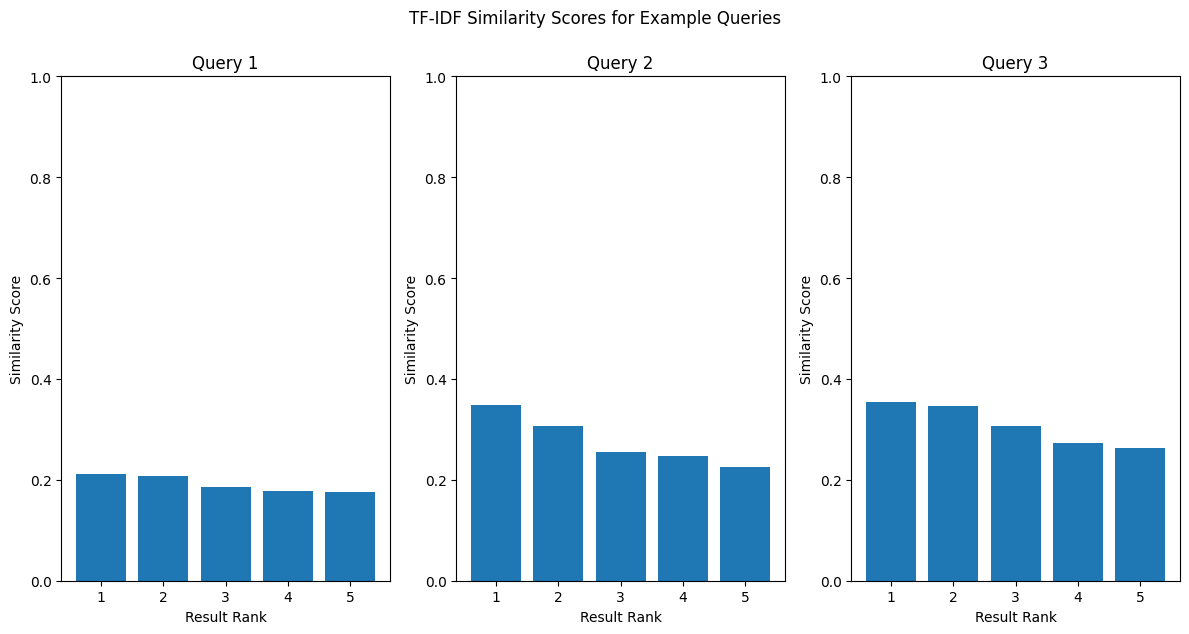

In [6]:
# Visualize the scores for each query
plt.figure(figsize=(12, 6))

for i, query in enumerate(example_queries):
    scores = [result['score'] for result in results[query]]
    plt.subplot(1, 3, i+1)
    plt.bar(range(1, len(scores)+1), scores)
    plt.title(f"Query {i+1}")
    plt.xlabel('Result Rank')
    plt.ylabel('Similarity Score')
    plt.ylim(0, 1)
    
plt.tight_layout()
plt.suptitle('TF-IDF Similarity Scores for Example Queries', y=1.05)
plt.savefig('../results/tfidf_scores.png')
plt.show()

Let's examine which terms in the queries contributed most to the retrieval.

In [7]:
def analyze_query_terms(query, vectorizer):
    """Analyze which terms in a query have the highest TF-IDF weights."""
    # Transform query to TF-IDF space
    query_vector = vectorizer.transform([query])
    
    # Get feature names
    feature_names = vectorizer.get_feature_names_out()
    
    # Get non-zero elements
    non_zero_indices = query_vector.nonzero()[1]
    
    # Get term weights
    term_weights = []
    for idx in non_zero_indices:
        term_weights.append((feature_names[idx], query_vector[0, idx]))
    
    # Sort by weight
    term_weights.sort(key=lambda x: x[1], reverse=True)
    
    return term_weights

# Analyze terms for each query
for i, query in enumerate(example_queries):
    print(f"\nQuery {i+1}: {query}")
    term_weights = analyze_query_terms(query, retriever.vectorizer)
    print("Top terms by weight:")
    for term, weight in term_weights[:10]:
        print(f"- {term}: {weight:.4f}")


Query 1: Harry's first day at Hogwarts
Top terms by weight:
- day: 0.7054
- hogwarts: 0.6699
- harry: 0.2316

Query 2: Quidditch match rules
Top terms by weight:
- quidditch match: 0.5629
- rules: 0.5524
- match: 0.4744
- quidditch: 0.3911

Query 3: Voldemort and the Philosopher's Stone
Top terms by weight:
- voldemort: 0.7705
- stone: 0.6375


## 5. Discuss the Limitations of TF-IDF

Let's discuss the main issues with the TF-IDF approach.

In [8]:
# Get the TF-IDF issues
issues = analyze_tfidf_issues()

# Print the issues
print("Main issues with TF-IDF approach:")
for issue in issues:
    print(f"\n{issue['issue']}:")
    print(f"  {issue['description']}")

Main issues with TF-IDF approach:

Lexical gap:
  TF-IDF cannot handle synonyms or semantically related terms that don't share the same tokens.

Term frequency bias:
  Common terms in specific contexts may be underweighted, while rare but irrelevant terms may be overweighted.

No understanding of word order or context:
  TF-IDF treats documents as bags of words, ignoring the order and context which can change meaning.

Cannot capture meaning behind polysemous words:
  Words with multiple meanings are treated the same, regardless of the context they appear in.

Limited by vocabulary in corpus:
  Can only match terms that appear in the corpus, making it vulnerable to vocabulary mismatch.


Let's demonstrate one of these issues with a concrete example: the lexical gap problem.

In [9]:
# Define two semantically similar queries with different wording
query1 = "Harry's scar hurts"
query2 = "Pain in Harry's forehead"

# Search with both queries
results1 = retriever.search(query1)
results2 = retriever.search(query2)

# Get the chunk IDs for both results
chunk_ids1 = [result['chunk_id'] for result in results1]
chunk_ids2 = [result['chunk_id'] for result in results2]

# Calculate overlap
common_chunks = set(chunk_ids1).intersection(set(chunk_ids2))
overlap_percentage = len(common_chunks) / len(chunk_ids1) * 100

print(f"Query 1: {query1}")
print(f"Query 2: {query2}")
print(f"\nOverlap in results: {len(common_chunks)} out of {len(chunk_ids1)} chunks ({overlap_percentage:.2f}%)")
print(f"Common chunk IDs: {common_chunks}")

# Print the first result for each query
print(f"\nFirst result for Query 1:")
print(f"Chunk ID: {results1[0]['chunk_id']}")
print(f"Score: {results1[0]['score']:.4f}")
print(f"Text: {results1[0]['text'][:200]}...")

print(f"\nFirst result for Query 2:")
print(f"Chunk ID: {results2[0]['chunk_id']}")
print(f"Score: {results2[0]['score']:.4f}")
print(f"Text: {results2[0]['text'][:200]}...")

Query 1: Harry's scar hurts
Query 2: Pain in Harry's forehead

Overlap in results: 2 out of 5 chunks (40.00%)
Common chunk IDs: {809, 922}

First result for Query 1:
Chunk ID: 922
Score: 0.2619
Text: At once, a needle-sharp pain seared across Harry's scar; his head felt as though it was about to split in two; he yelled, struggling with all his might, and to his surprise, Quirrell let go of him. Th...

First result for Query 2:
Chunk ID: 396
Score: 0.2507
Text: Professor McGonagall was talking to Professor Dumbledore. Professor Quirrell, in his absurd turban, was talking to a teacher with greasy black hair, a hooked nose, and sallow skin. It happened very su...


## Summary

In this notebook, we've:
1. Loaded the preprocessed text chunks
2. Initialized the TF-IDF retriever
3. Performed example searches
4. Analyzed the results
5. Discussed the limitations of TF-IDF

We've seen that TF-IDF can be effective for lexical retrieval, but it has several limitations, particularly the lexical gap problem where semantically similar queries with different wording can produce very different results.

In the next notebook, we'll explore semantic search using the miniLM model, which can help address some of these limitations.